# HEALTH DISEASE DETECTION USING MACHINE LEARNING  

#### Model developed by Abhijit Saikia, Debraj Singh & Jyotiraj Nath

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# warnings removal
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score
from sklearn.feature_selection import RFE,SelectKBest,SelectFromModel
from sklearn.model_selection import GridSearchCV,cross_val_score,StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

### Preprocessing of data

In [2]:
# Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
# checking train_df
train_df.head()

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse


In [4]:
print('train shape:',train_df.shape)
print('test shape: ',test_df.shape)

train shape: (2351, 25)
test shape:  (486, 25)


In [5]:
train_df.dtypes

Glucose                                      float64
Cholesterol                                  float64
Hemoglobin                                   float64
Platelets                                    float64
White Blood Cells                            float64
Red Blood Cells                              float64
Hematocrit                                   float64
Mean Corpuscular Volume                      float64
Mean Corpuscular Hemoglobin                  float64
Mean Corpuscular Hemoglobin Concentration    float64
Insulin                                      float64
BMI                                          float64
Systolic Blood Pressure                      float64
Diastolic Blood Pressure                     float64
Triglycerides                                float64
HbA1c                                        float64
LDL Cholesterol                              float64
HDL Cholesterol                              float64
ALT                                          f

In [6]:
# check missing values
print('train_df missing values: ',train_df.isna().sum().sum())
print('test_df missing values: ',test_df.isna().sum().sum())

train_df missing values:  0
test_df missing values:  0


In [7]:
# Unique variables in the target column of the training set.
print('-------train set-------')
print(f'Unique variables in the target column: {train_df.Disease.unique()}\nthe number of unique variables in the target column: {train_df.Disease.nunique()}\n')
# Unique variables in the target column of the test set.
print('-------test set-------')
print(f'Unique variables in the target column: {test_df.Disease.unique()}\nthe number of unique variables in the target column: {test_df.Disease.nunique()}')

-------train set-------
Unique variables in the target column: ['Healthy' 'Diabetes' 'Thalasse' 'Anemia' 'Thromboc']
the number of unique variables in the target column: 5

-------test set-------
Unique variables in the target column: ['Thalasse' 'Diabetes' 'Heart Di' 'Anemia' 'Thromboc' 'Healthy']
the number of unique variables in the target column: 6


In [8]:
# combine 2 data frames.
data = pd.concat([train_df,test_df],ignore_index=True)

In [9]:
#check new data frame.
data.head()

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse


In [10]:
data.shape # (rows, columns)

(2837, 25)

In [11]:
# find number of each class 
data.Disease.value_counts()

Disease
Diabetes    834
Anemia      707
Healthy     561
Thalasse    557
Thromboc    139
Heart Di     39
Name: count, dtype: int64

In [12]:
# convert target column to numeric values.
data.Disease = data.Disease.astype('category')
d = dict(enumerate(data['Disease'].cat.categories))
data.Disease = data.Disease.cat.codes.values
data.Disease

0       2
1       1
2       4
3       0
4       4
       ..
2832    1
2833    3
2834    0
2835    1
2836    1
Name: Disease, Length: 2837, dtype: int8

In [13]:
# Print the mapping dictionary
print("Mapping of numeric values to disease names:")
for numeric_value, disease_name in d.items():
    print(f"{numeric_value}: {disease_name}")


Mapping of numeric values to disease names:
0: Anemia
1: Diabetes
2: Healthy
3: Heart Di
4: Thalasse
5: Thromboc


Text(0.5, 1.0, 'Correlation Heatmap')

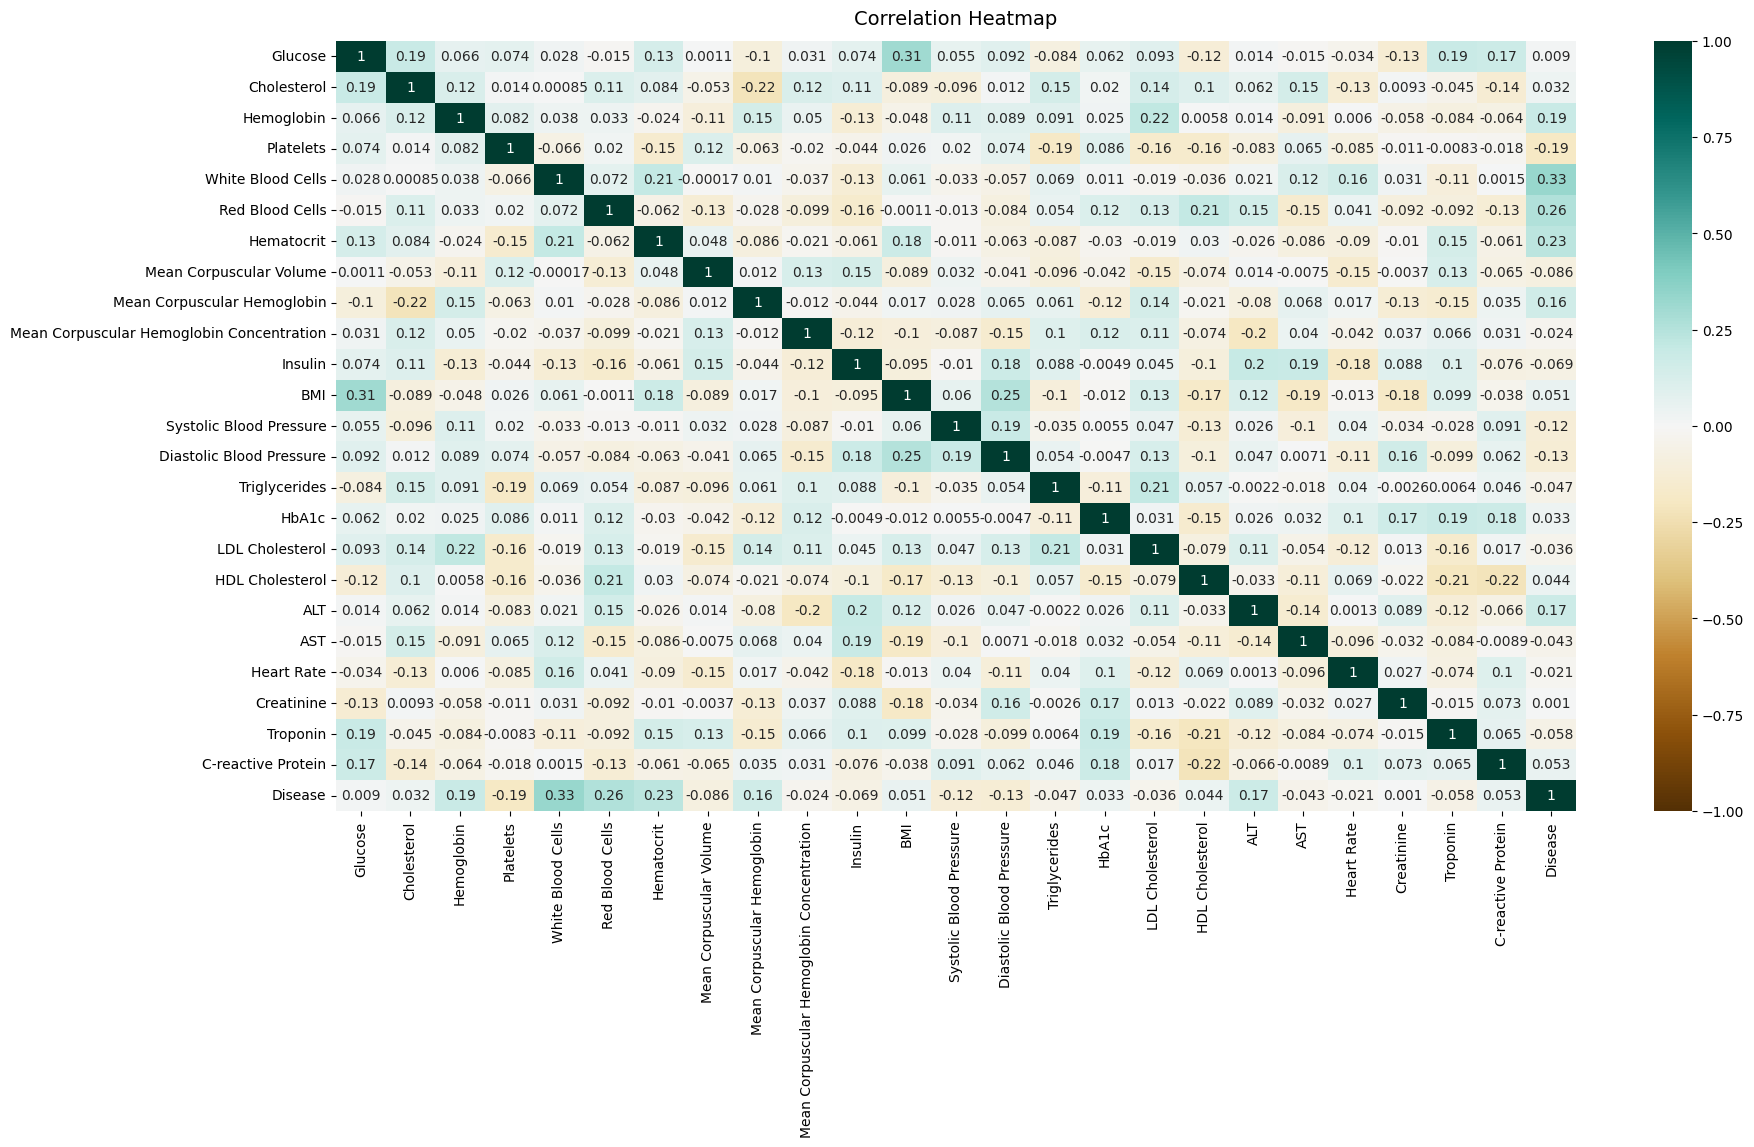

In [14]:
# correlation matrix
plt.figure(figsize=(20, 10))
heatmap = sns.heatmap(data.corr(), vmin=-1, vmax=1, annot=True,cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12)

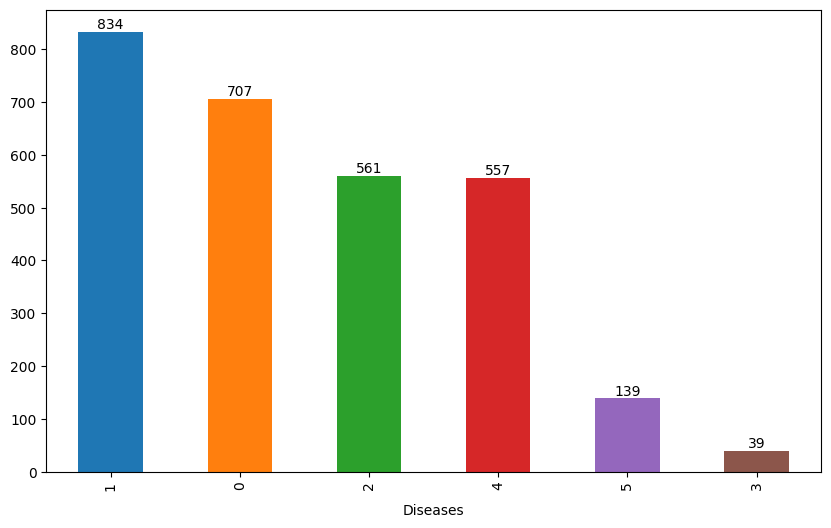

In [15]:
#  number of each class there are in the bar chart.
counts = data[data.columns[-1]].value_counts()
palette = sns.color_palette()
fig, axes = plt.subplots(figsize=(10,6))
counts.plot(kind="bar", ax=axes, color=palette)
plt.xlabel('Diseases',labelpad=10)
for container in axes.containers:
    axes.bar_label(container)
plt.show()


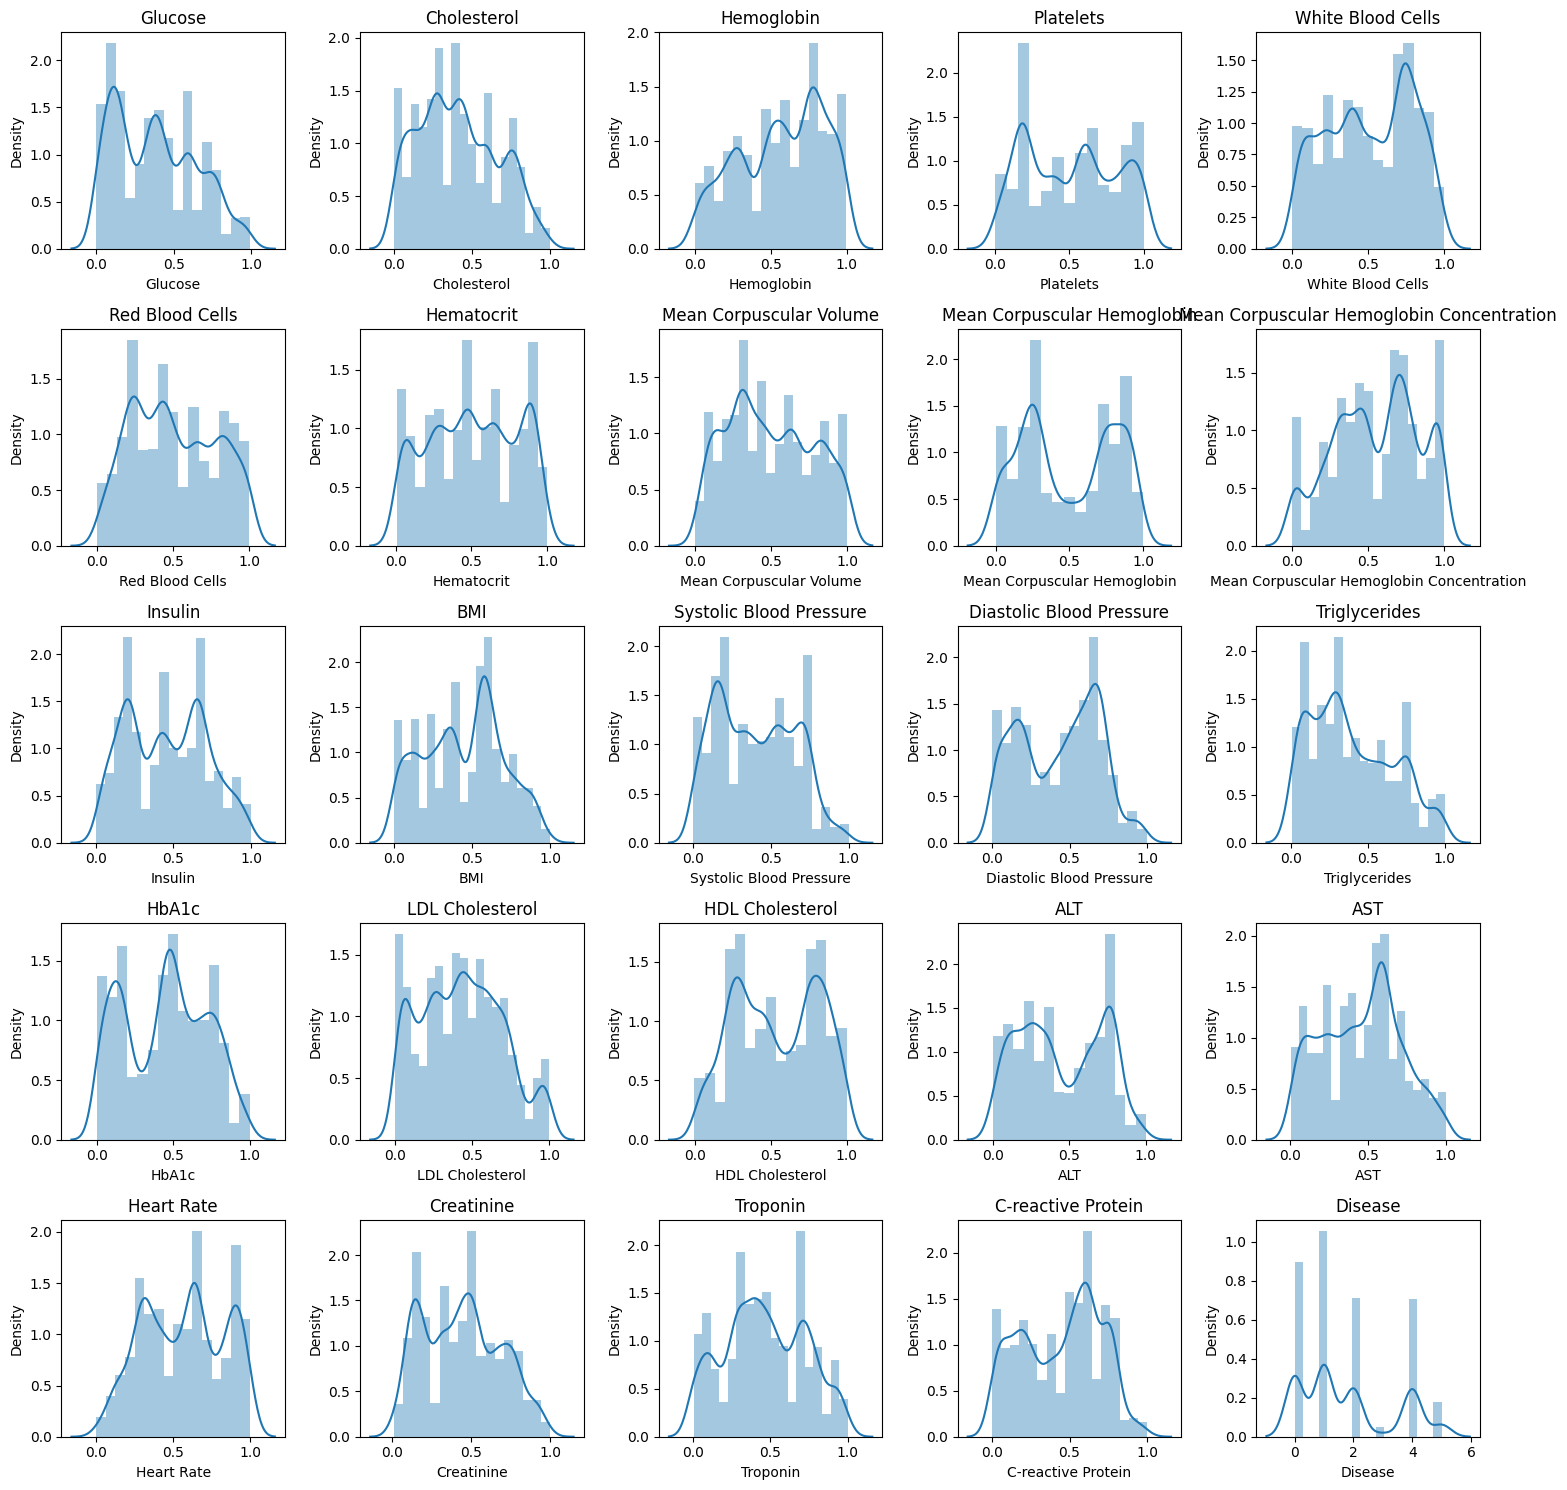

In [16]:

#It creates a grid of subplots with 5 rows and 5 columns, making a total of 25 subplots.
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(15, 15))

# Draw a distplot for each column and add it to the subplot
for i, col in enumerate(data.columns):
    sns.distplot(data[col], ax=axs[i//5, i%5])
    axs[i//5, i%5].set_title(col)

# Hide missing subplots
for i in range(len(data.columns), 25):
    axs[i//5, i%5].axis('off')

#  Show charts
plt.tight_layout()
plt.show()

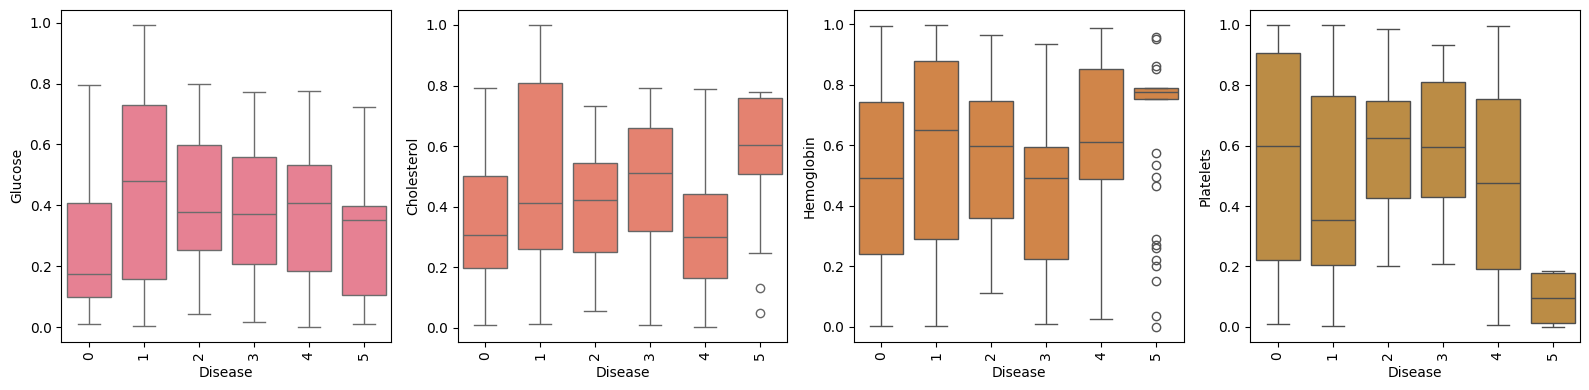

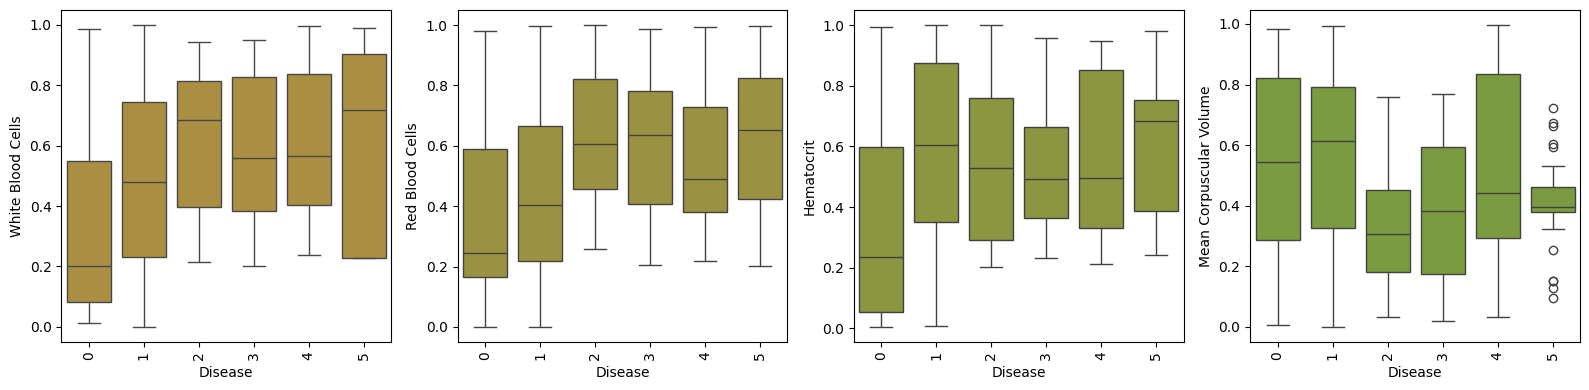

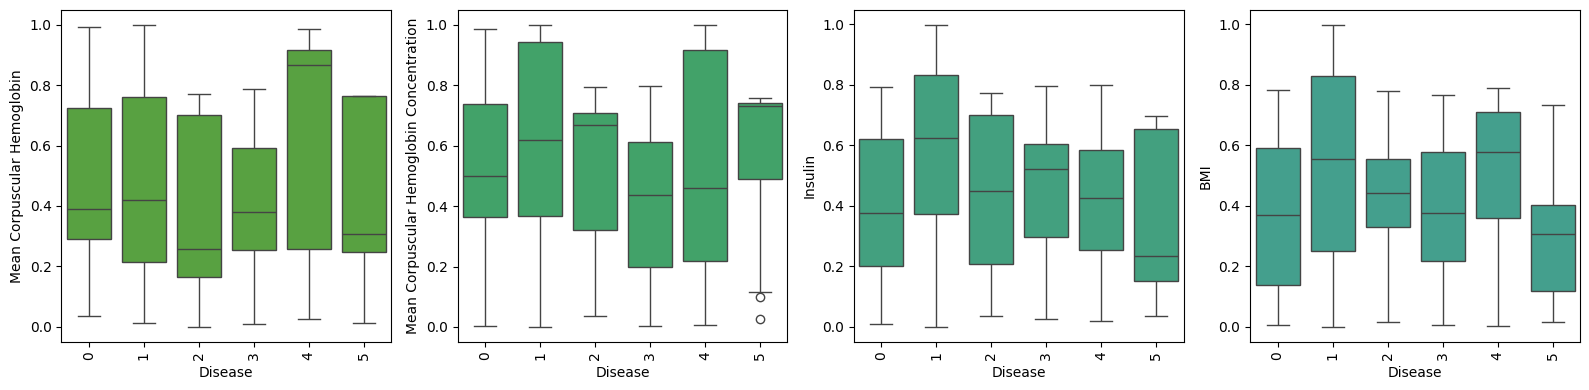

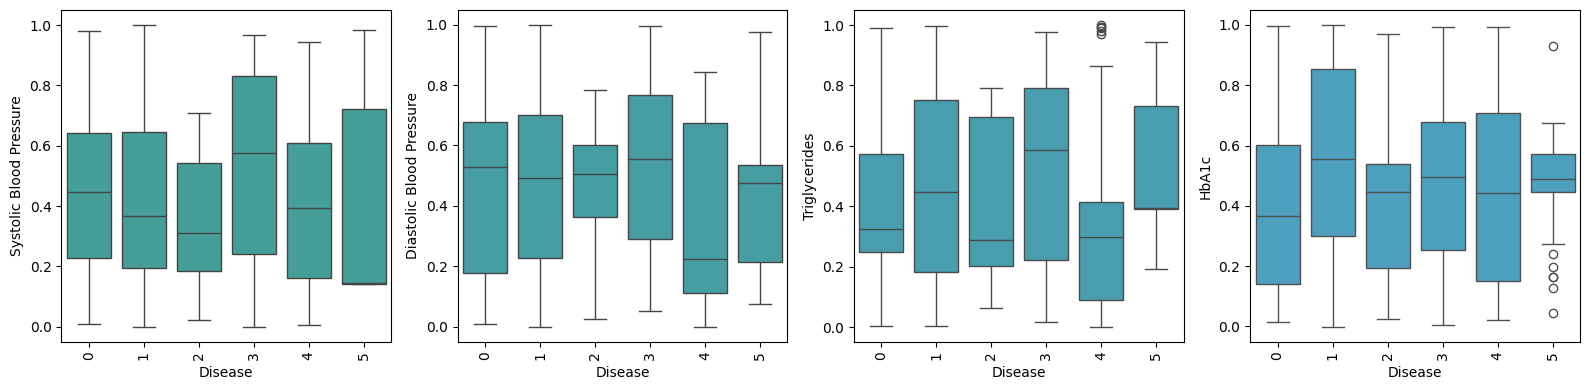

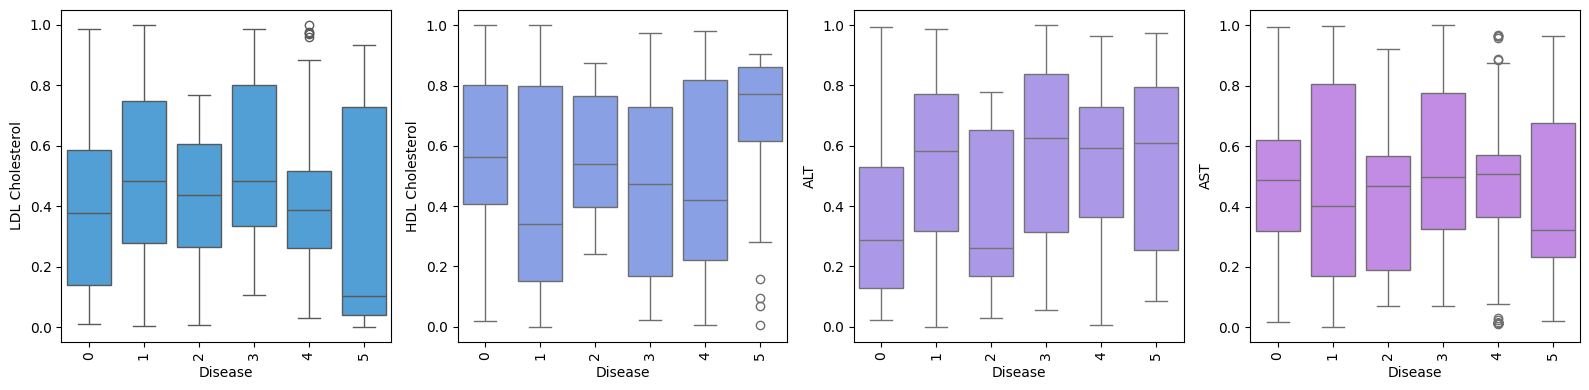

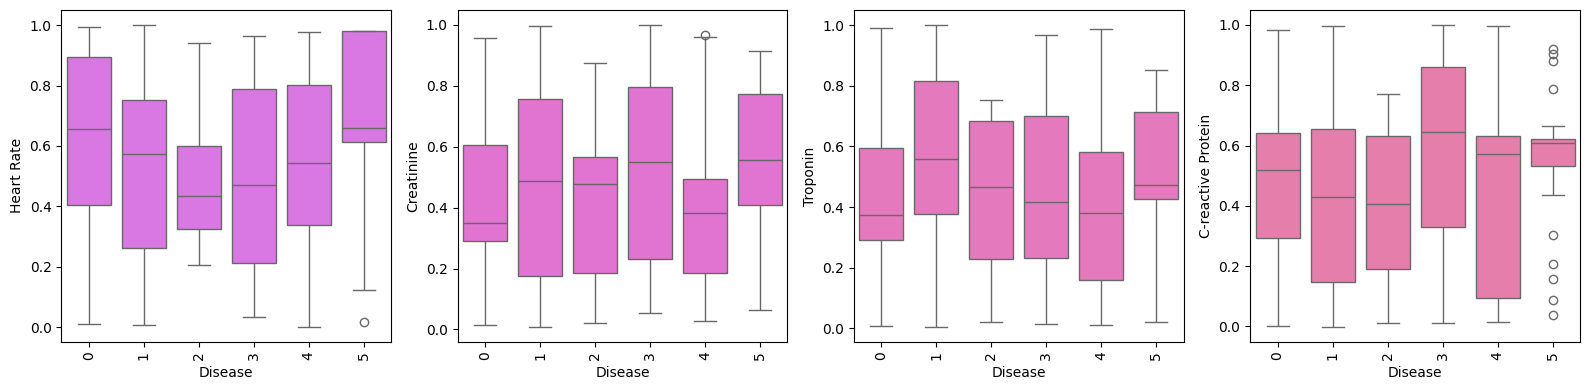

In [17]:
# Draw a boxplot for each column
index = 0
palette = sns.color_palette("husl", len(data.columns) - 1)

for i in range(0, len(data.columns) - 1, 4):
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
    for j, ax in enumerate(axes.flat):
        if index < len(data.columns) - 1:
            sns.boxplot(data=data, x=data.columns[-1], y=data.columns[index], ax=ax, palette=[palette[index]])
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
            index += 1
    plt.tight_layout()
    plt.show()


In [18]:
data['Hemoglobin'].describe()

count    2837.000000
mean        0.568941
std         0.278908
min         0.000719
25%         0.325035
50%         0.597916
75%         0.791215
max         0.997876
Name: Hemoglobin, dtype: float64

In [19]:
X = data.drop('Disease',axis=1)
y = data['Disease']

In [20]:
print("Features (X):")
print(X.head())

Features (X):
    Glucose  Cholesterol  Hemoglobin  Platelets  White Blood Cells  \
0  0.739597     0.650198    0.713631   0.868491           0.687433   
1  0.121786     0.023058    0.944893   0.905372           0.507711   
2  0.452539     0.116135    0.544560   0.400640           0.294538   
3  0.136609     0.015605    0.419957   0.191487           0.081168   
4  0.176737     0.752220    0.971779   0.785286           0.443880   

   Red Blood Cells  Hematocrit  Mean Corpuscular Volume  \
0         0.529895    0.290006                 0.631045   
1         0.403033    0.164216                 0.307553   
2         0.382021    0.625267                 0.295122   
3         0.166214    0.073293                 0.668719   
4         0.439851    0.894991                 0.442159   

   Mean Corpuscular Hemoglobin  Mean Corpuscular Hemoglobin Concentration  \
0                     0.001328                                   0.795829   
1                     0.207938                          

In [21]:
print("\nTarget (y):")
print(y.head())


Target (y):
0    2
1    1
2    4
3    0
4    4
Name: Disease, dtype: int8


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=10,stratify= y)

In [24]:
results = pd.DataFrame([],columns=['Accuracy','train Accuracy'])

In [25]:
print('train shape:',X_train.shape)
print('test shape: ',X_test.shape)

train shape: (2269, 24)
test shape:  (568, 24)


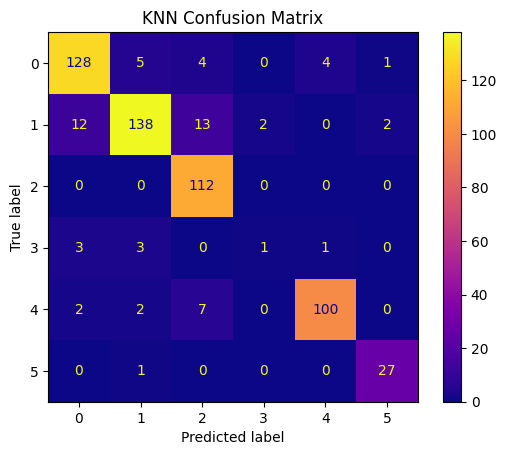

KNN Accuracy: 0.8908450704225352
KNN Train Accuracy: 0.9237549581313353
KNN AUC Score: 0.9388295538618882


In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)  
knn_model.fit(X_train_scaled, y_train)

# Model evaluation
knn_y_pred = knn_model.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_y_pred)
knn_train_acc = accuracy_score(y_train, knn_model.predict(X_train_scaled))

# AUC score
knn_y_proba = knn_model.predict_proba(X_test_scaled)
knn_score = roc_auc_score(y_test, knn_y_proba, multi_class='ovr', average='macro')

# Confusion matrix
knn_disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, knn_y_pred),
                                  display_labels=knn_model.classes_)
knn_disp.plot(cmap='plasma')

results.loc['KNN'] = [knn_acc, knn_train_acc]

# Display metrics
plt.title('KNN Confusion Matrix')
plt.show()

print('KNN Accuracy:', knn_acc)
print('KNN Train Accuracy:', knn_train_acc)
print('KNN AUC Score:', knn_score)


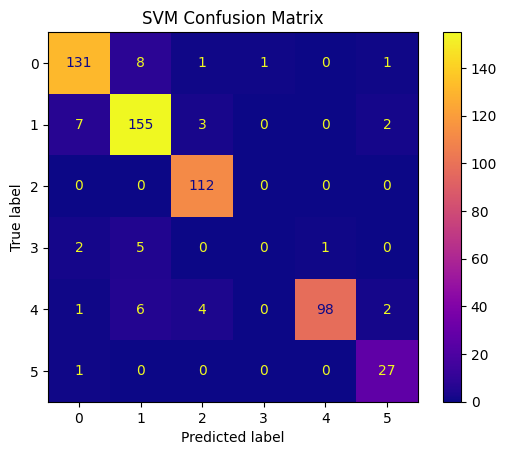

SVM Accuracy: 0.920774647887324
SVM Train Accuracy: 0.9347730277655355
SVM AUC Score: 0.9606023415249685


In [28]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create SVM model
svm_model = SVC(kernel='linear', probability=True, C=1.0, random_state=10)  # You can adjust parameters as needed
svm_model.fit(X_train_scaled, y_train)

# Model evaluation
svm_y_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_y_pred)
svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train_scaled))

# AUC score
svm_y_proba = svm_model.predict_proba(X_test_scaled)
svm_score = roc_auc_score(y_test, svm_y_proba, multi_class='ovr', average='macro')

# Confusion matrix
svm_disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, svm_y_pred),
                                  display_labels=svm_model.classes_)
svm_disp.plot(cmap='plasma')

results.loc['SVM'] = [svm_acc, svm_train_acc]

# Display metrics
plt.title('SVM Confusion Matrix')
plt.show()

print('SVM Accuracy:', svm_acc)
print('SVM Train Accuracy:', svm_train_acc)
print('SVM AUC Score:', svm_score)


In [29]:
mdl = DecisionTreeClassifier()

path= mdl.cost_complexity_pruning_path(X_train,y_train)
path['ccp_alphas']

array([0.        , 0.00044072, 0.00044072, 0.00044072, 0.00058763,
       0.00058763, 0.00058763, 0.00077126, 0.00078351, 0.0007933 ,
       0.0007933 , 0.0008539 , 0.00085474, 0.00086588, 0.00086898,
       0.00087313, 0.00087537, 0.00087581, 0.00087726, 0.00088145,
       0.00100567, 0.00105773, 0.00106234, 0.00107977, 0.00110181,
       0.00113329, 0.00120791, 0.00125436, 0.00125606, 0.00125921,
       0.00131167, 0.00141091, 0.00151105, 0.00164537, 0.00173851,
       0.00195244, 0.00196798, 0.00201187, 0.00210224, 0.00247818,
       0.00255512, 0.00259468, 0.00261621, 0.00305877, 0.00361549,
       0.00453789, 0.00474187, 0.00504565, 0.00589325, 0.00630737,
       0.00705207, 0.00722858, 0.00794026, 0.01063061, 0.01141317,
       0.01161575, 0.01279897, 0.01663738, 0.01690359, 0.01738795,
       0.01774828, 0.02231182, 0.02241917, 0.02731697, 0.03154103,
       0.03405757, 0.03817191, 0.05442068, 0.05642132, 0.06872152])

In [30]:
# standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# create model
mdl = DecisionTreeClassifier(random_state=2,max_features=18,ccp_alpha=0.002478180717510433)
# model fit
mdl.fit(X_train_scaled,y_train)
# test set predict
y_pred = mdl.predict(X_test_scaled)
# train set predict
y_tpred = mdl.predict(X_train_scaled)

train_score = accuracy_score(y_train,y_tpred)
score = accuracy_score(y_test,y_pred)
print('DecisionTreeClassifier accuracy is:',score)
print('DecisionTreeClassifier train accuracy is:',train_score)

results.loc['DecisionTreeClassifier'] = [score,train_score]

DecisionTreeClassifier accuracy is: 0.9383802816901409
DecisionTreeClassifier train accuracy is: 0.9673865138827678


In [31]:
from sklearn import tree

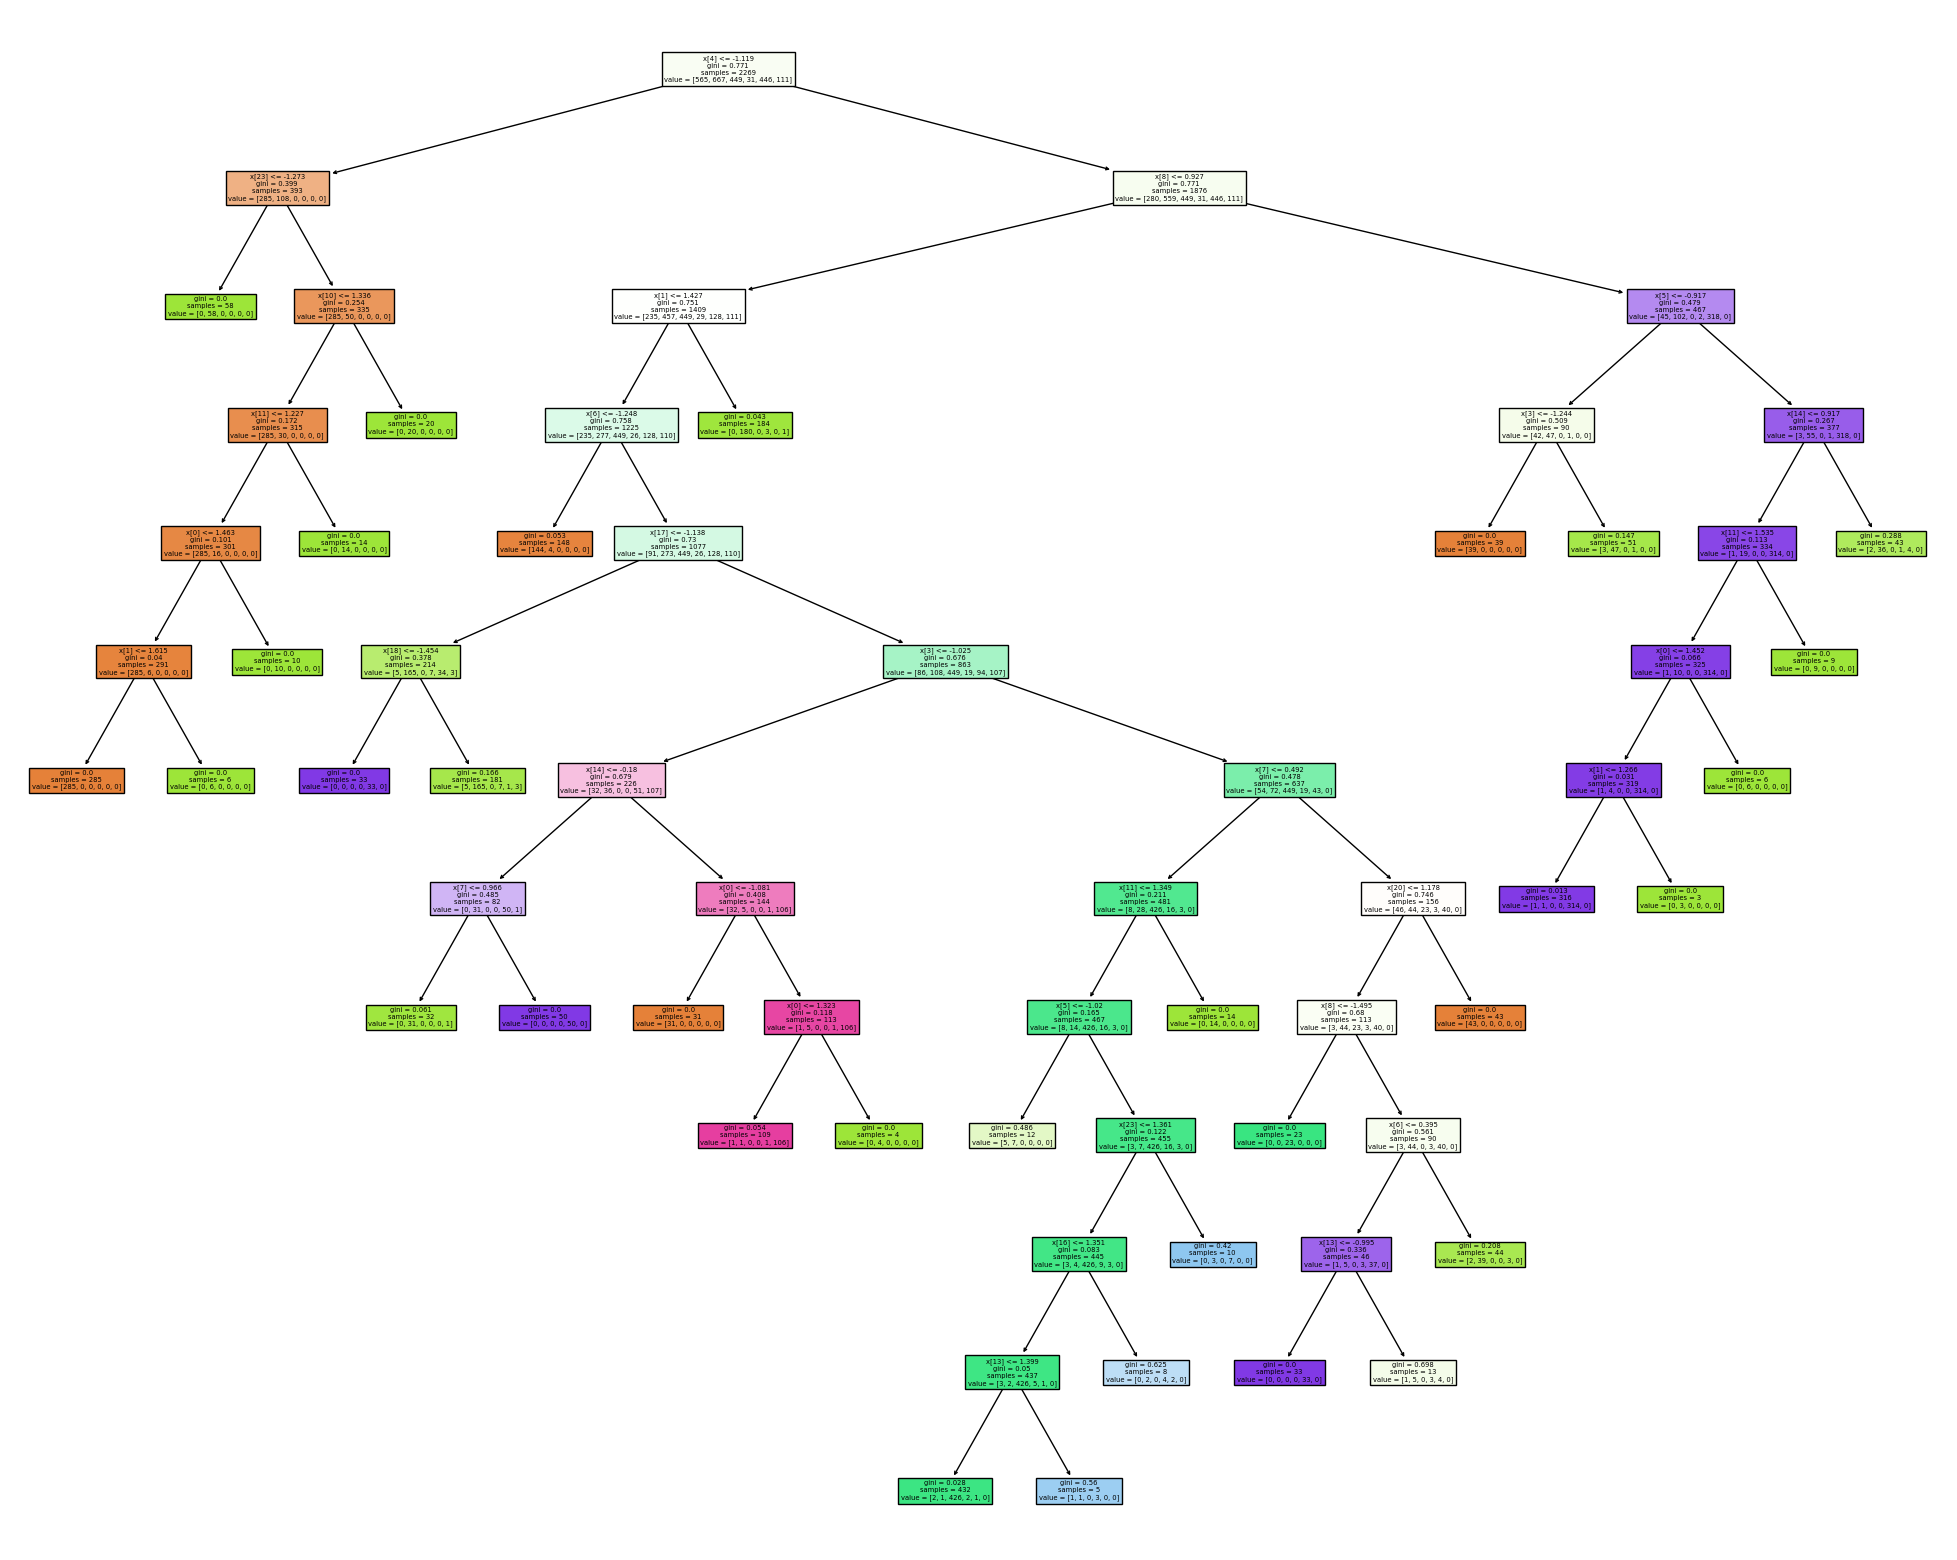

In [32]:
# plot tree
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(mdl,filled=True)

In [33]:
#logistic Regression

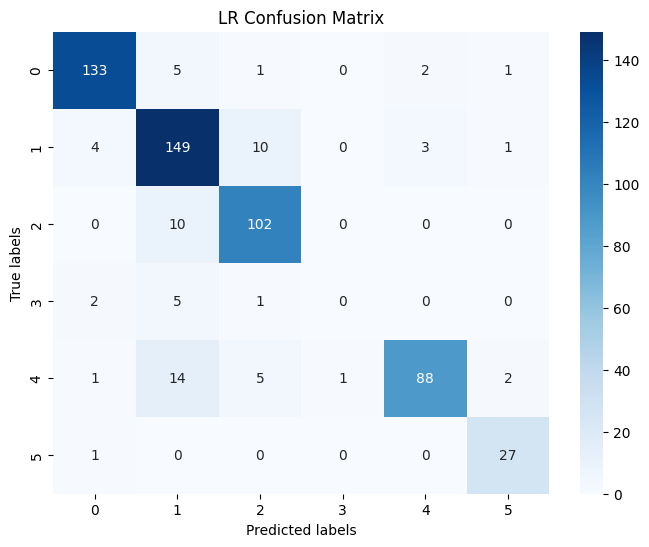

LogisticRegression accuracy is: 0.8785211267605634


In [47]:
# standardization
scaler = StandardScaler()
X_train_reduced = scaler.fit_transform(X_train)
X_test_reduced = scaler.transform(X_test)

# Create model
logmodel = LogisticRegression(max_iter= 1000, solver = 'saga', penalty= 'l1',
                              random_state = 10, C = 1.0, multi_class = 'multinomial')
# model fit
logmodel.fit(X_train_reduced,y_train)
# test set predict
y_pred = logmodel.predict(X_test_reduced)
# train set predict
train_pred = logmodel.predict(X_train_reduced)

#logmodel_train = accuracy_score(y_train,train_pred)
logmodel_acc = accuracy_score(y_test,y_pred)

results.loc['LogisticRegression'] = [logmodel_acc,logmodel_train]

# Calculate confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('LR Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()


print('LogisticRegression accuracy is:',logmodel_acc)

In [35]:
results

,Accuracy,train Accuracy
KNN,0.890845,0.923755
SVM,0.920775,0.934773
DecisionTreeClassifier,0.938380,0.967387
LogisticRegression,0.878521,0.878801


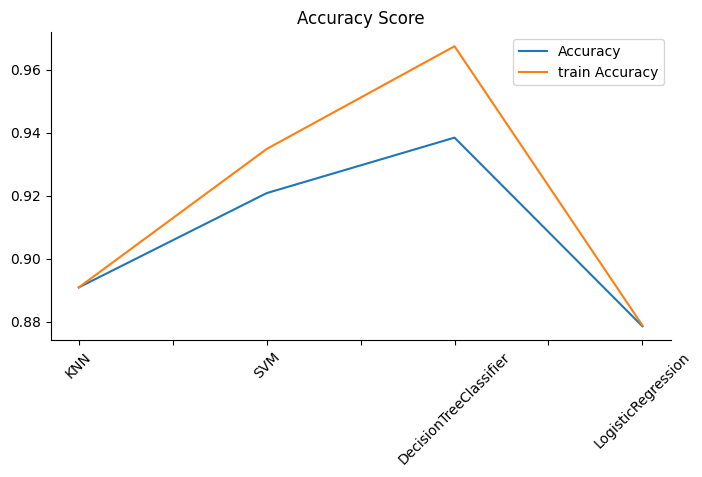

In [36]:
# # Accuracy scores of models
# results.loc['ANN Model', 'Accuracy'] = ann_acc[1]
# results.loc['ANN Model', 'train Accuracy'] = train_accuracy[1]

results.loc['KNN', 'Accuracy'] = knn_acc
results.loc['KNN', 'train Accuracy'] = knn_acc

results.loc['LogisticRegression', 'Accuracy'] = logmodel_acc
results.loc['LogisticRegression', 'train Accuracy'] = logmodel_train

# Plotting accuracy scores
results[['Accuracy', 'train Accuracy']].plot(kind='line', figsize=(8, 4), title='Accuracy Score')
plt.gca().spines['top'].set_visible(False)

plt.gca().spines['right'].set_visible(False)  # Hide the right spine
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
plt.show()

Ensemble Model Accuracy: 0.9295774647887324
Ensemble Model Train Accuracy: 0.9506390480387836
Ensemble Model Evaluation:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       142
           1       0.89      0.93      0.91       167
           2       0.90      1.00      0.95       112
           3       0.00      0.00      0.00         8
           4       0.99      0.90      0.94       111
           5       0.90      0.96      0.93        28

    accuracy                           0.93       568
   macro avg       0.77      0.79      0.78       568
weighted avg       0.92      0.93      0.92       568



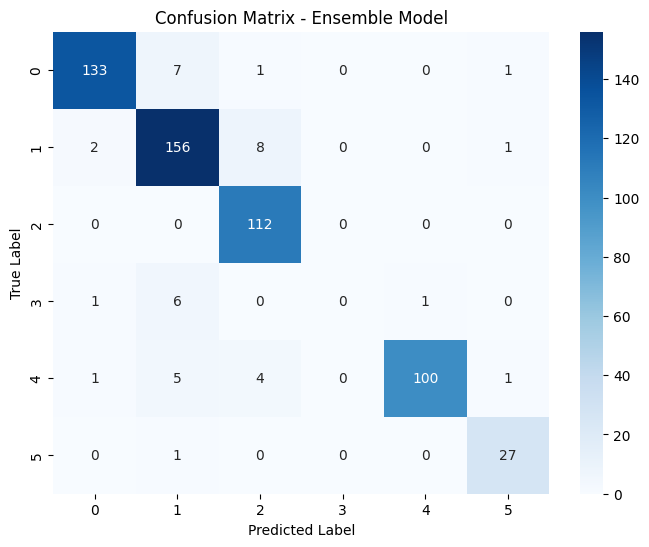

Best SVM Parameters: {'C': 10, 'kernel': 'rbf'}
Best Logistic Regression Parameters: {'C': 10, 'penalty': 'l1'}
Best KNN Parameters: {'n_neighbors': 3}
Best Decision Tree Parameters: {'max_depth': None, 'min_samples_split': 10}


In [37]:

from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier

# Define individual models
svm_model = SVC(kernel='linear', probability=True, C=1.0, random_state=10)
logmodel = LogisticRegression(max_iter=1000, solver='saga', penalty='l1', random_state=10, C=1.0, multi_class='multinomial')
knn_model = KNeighborsClassifier(n_neighbors=5)
dt_model = DecisionTreeClassifier(random_state=2, max_features=18, ccp_alpha=0.002478180717510433)

# Create ensemble model
ensemble_model = VotingClassifier(estimators=[('svm', svm_model), ('logistic', logmodel), ('knn', knn_model), ('dt', dt_model)], voting='soft')

# Fit ensemble model
ensemble_model.fit(X_train_scaled, y_train)

# Predictions
ensemble_y_pred = ensemble_model.predict(X_test_scaled)
ensemble_y_train_pred = ensemble_model.predict(X_train_scaled)

# Model evaluation
ensemble_acc = accuracy_score(y_test, ensemble_y_pred)
ensemble_train_acc = accuracy_score(y_train, ensemble_y_train_pred)

# Display metrics
print('Ensemble Model Accuracy:', ensemble_acc)
#print('Ensemble Model Train Accuracy:', ensemble_train_acc)



from sklearn.metrics import classification_report

# Evaluation
print("Ensemble Model Evaluation:")
print(classification_report(y_test, ensemble_y_pred))

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, ensemble_y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Ensemble Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



In [ ]:
# Hyperparameter Tuning
# As you're using pre-defined models within the ensemble, you can individually tune their hyperparameters.
# For example, you can use GridSearchCV to find the best hyperparameters for each base model.

from sklearn.model_selection import GridSearchCV

# Define hyperparameters for individual models
svm_params = {'kernel': ['linear', 'poly', 'rbf'], 'C': [0.1, 1, 10]}
logistic_params = {'penalty': ['l1', 'l2'], 'C': [0.1, 1, 10]}
knn_params = {'n_neighbors': [3, 5, 7]}
dt_params = {'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}

# Perform GridSearchCV for each base model
svm_grid = GridSearchCV(SVC(probability=True, random_state=10), svm_params, cv=5)
svm_grid.fit(X_train_scaled, y_train)

logistic_grid = GridSearchCV(LogisticRegression(max_iter=1000, solver='saga', multi_class='multinomial', random_state=10),
                             logistic_params, cv=5)
logistic_grid.fit(X_train_scaled, y_train)

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_grid.fit(X_train_scaled, y_train)

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=2), dt_params, cv=5)
dt_grid.fit(X_train_scaled, y_train)

# After tuning, you can access the best hyperparameters and their respective scores for each model
print("Best SVM Parameters:", svm_grid.best_params_)
print("Best Logistic Regression Parameters:", logistic_grid.best_params_)
print("Best KNN Parameters:", knn_grid.best_params_)
print("Best Decision Tree Parameters:", dt_grid.best_params_)


In [38]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier

# Define individual models (excluding DecisionTreeClassifier)
svm_model = SVC(kernel='linear', probability=True, C=1.0, random_state=10)
logmodel = LogisticRegression(max_iter=1000, solver='saga', penalty='l1', random_state=10, C=1.0, multi_class='multinomial')
knn_model = KNeighborsClassifier(n_neighbors=5)

# Create ensemble model (without DecisionTreeClassifier)
ensemble_model = VotingClassifier(estimators=[('svm', svm_model), ('logistic', logmodel), ('knn', knn_model)], voting='soft')



In [39]:
# Fit ensemble model
ensemble_model.fit(X_train_scaled, y_train)



VotingClassifier(estimators=[('svm',
                              SVC(kernel='linear', probability=True,
                                  random_state=10)),
                             ('logistic',
                              LogisticRegression(max_iter=1000,
                                                 multi_class='multinomial',
                                                 penalty='l1', random_state=10,
                                                 solver='saga')),
                             ('knn', KNeighborsClassifier())],
                 voting='soft')

In [40]:
# Predictions
ensemble_y_pred = ensemble_model.predict(X_test_scaled)
ensemble_y_train_pred = ensemble_model.predict(X_train_scaled)

# Model evaluation
ensemble_acc = accuracy_score(y_test, ensemble_y_pred)
ensemble_train_acc = accuracy_score(y_train, ensemble_y_train_pred)



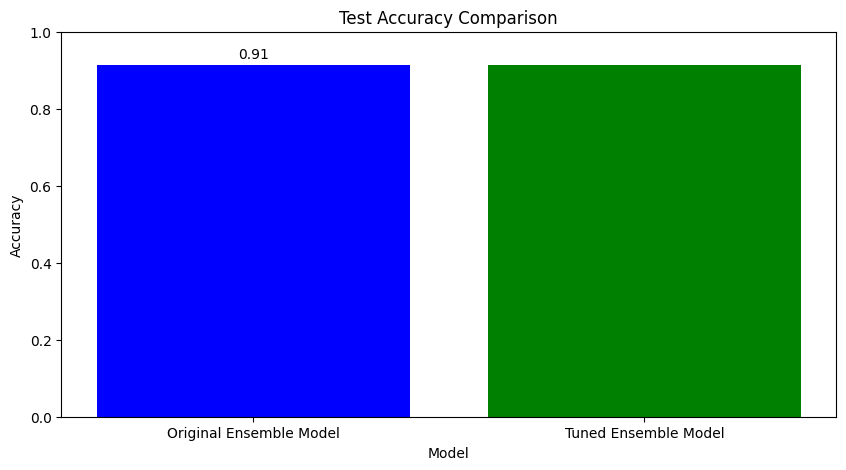

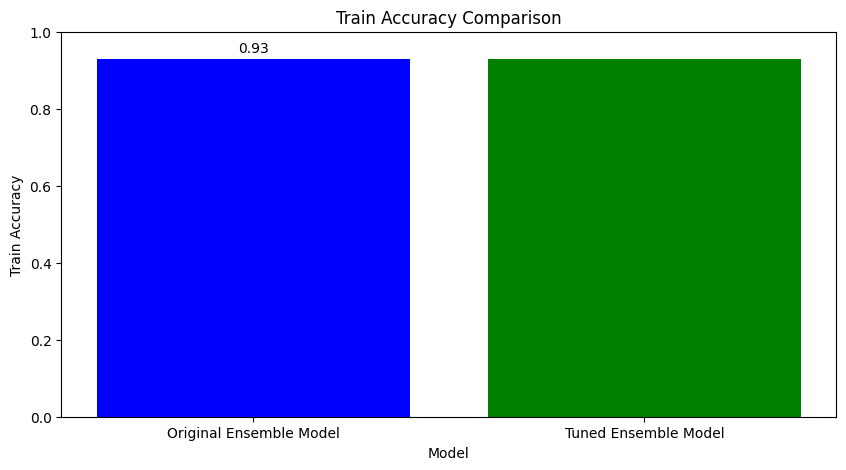

In [41]:
import matplotlib.pyplot as plt

# Define accuracy values
model_names = ['Original Ensemble Model', 'Tuned Ensemble Model']
accuracies = [ensemble_acc]  # Assuming you only have accuracy for the original model
train_accuracies = [ensemble_train_acc]  # Assuming you only have train accuracy for the original model

# Plot test accuracies
plt.figure(figsize=(10, 5))
plt.bar(model_names, accuracies, color=['blue', 'green'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Test Accuracy Comparison')
plt.ylim(0, 1)  # Ensure the y-axis starts at 0 and ends at 1
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center', va='bottom')
plt.show()

# Plot train accuracies
plt.figure(figsize=(10, 5))
plt.bar(model_names, train_accuracies, color=['blue', 'green'])
plt.xlabel('Model')
plt.ylabel('Train Accuracy')
plt.title('Train Accuracy Comparison')
plt.ylim(0, 1)  # Ensure the y-axis starts at 0 and ends at 1
for i, acc in enumerate(train_accuracies):
    plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center', va='bottom')
plt.show()


In [42]:
# Display metrics
print('Ensemble Model Accuracy:', ensemble_acc)
print('Ensemble Model Train Accuracy:', ensemble_train_acc)

# Hyperparameter Tuning (excluding DecisionTreeClassifier)
from sklearn.model_selection import GridSearchCV

# Define hyperparameters for individual models (excluding DecisionTreeClassifier)
svm_params = {'kernel': ['linear', 'poly', 'rbf'], 'C': [0.1, 1, 10]}
logistic_params = {'penalty': ['l1', 'l2'], 'C': [0.1, 1, 10]}
knn_params = {'n_neighbors': [3, 5, 7]}

# Perform GridSearchCV for each base model (excluding DecisionTreeClassifier)
svm_grid = GridSearchCV(SVC(probability=True, random_state=10), svm_params, cv=5)
svm_grid.fit(X_train_scaled, y_train)

logistic_grid = GridSearchCV(LogisticRegression(max_iter=1000, solver='saga', multi_class='multinomial', random_state=10),
                             logistic_params, cv=5)
logistic_grid.fit(X_train_scaled, y_train)

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_grid.fit(X_train_scaled, y_train)

# After tuning, you can access the best hyperparameters and their respective scores for each model
print("Best SVM Parameters:", svm_grid.best_params_)
print("Best Logistic Regression Parameters:", logistic_grid.best_params_)
print("Best KNN Parameters:", knn_grid.best_params_)

# Update individual models with best hyperparameters (excluding DecisionTreeClassifier)
svm_model_tuned = SVC(probability=True, random_state=10, **svm_grid.best_params_)
logistic_model_tuned = LogisticRegression(max_iter=1000, solver='saga', multi_class='multinomial', random_state=10,
                                          **logistic_grid.best_params_)
knn_model_tuned = KNeighborsClassifier(**knn_grid.best_params_)

# Update ensemble model with tuned base models (excluding DecisionTreeClassifier)
ensemble_model_tuned = VotingClassifier(estimators=[('svm', svm_model_tuned), ('logistic', logistic_model_tuned),
                                                    ('knn', knn_model_tuned)], voting='soft')

# Retrain ensemble model with tuned base models
ensemble_model_tuned.fit(X_train_scaled, y_train)

# Predictions using the tuned ensemble model
ensemble_y_pred_tuned = ensemble_model_tuned.predict(X_test_scaled)
ensemble_y_train_pred_tuned = ensemble_model_tuned.predict(X_train_scaled)

# Model evaluation for tuned ensemble model
ensemble_acc_tuned = accuracy_score(y_test, ensemble_y_pred_tuned)
ensemble_train_acc_tuned = accuracy_score(y_train, ensemble_y_train_pred_tuned)

# Display metrics for tuned ensemble model
print('Tuned Ensemble Model Accuracy:', ensemble_acc_tuned)
print('Tuned Ensemble Model Train Accuracy:', ensemble_train_acc_tuned)

# Compare performance with previous ensemble model
print('Improvement in Accuracy:', ensemble_acc_tuned - ensemble_acc)
print('Improvement in Train Accuracy:', ensemble_train_acc_tuned - ensemble_train_acc)


Ensemble Model Accuracy: 0.9137323943661971
Ensemble Model Train Accuracy: 0.9286029087703834
Best SVM Parameters: {'C': 10, 'kernel': 'rbf'}
Best Logistic Regression Parameters: {'C': 10, 'penalty': 'l1'}
Best KNN Parameters: {'n_neighbors': 3}
Tuned Ensemble Model Accuracy: 0.926056338028169
Tuned Ensemble Model Train Accuracy: 0.988541207580432
Improvement in Accuracy: 0.01232394366197187
Improvement in Train Accuracy: 0.05993829881004853


In [43]:
import joblib

# Save the tuned ensemble model
joblib.dump(ensemble_model, 'ensemble_model.joblib')

# Save the scaler used during training
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [44]:

import joblib

# Load the tuned ensemble model from disk
ensemble_model_loaded = joblib.load('ensemble_model.joblib')

# Load the scaler (if saved during training)
scaler_loaded = joblib.load('scaler.joblib')


In [45]:
# Define a function to preprocess input data
def preprocess_input(input_data):
    # Apply the same preprocessing steps used during training
    input_scaled = scaler_loaded.transform(input_data)
    return input_scaled

# Example input data (replace this with your own input data)
input_data = [
    [0.596150211, 0.294838787, 0.261009735, 0.617652055, 0.129569135, 0.245357932, 0.035437329, 0.287531761, 0.056466444, 0.80049658, 0.583976352, 0.032616941, 0.555189544, 0.678200484, 0.00521692, 0.738542493, 0.075263134, 0.250967627, 0.066292341, 0.71042749, 0.893396796, 0.704436788, 0.590517395, 0.728162945]
    # Add more samples as needed
]

In [46]:
# Preprocess the input data
input_data_scaled = preprocess_input(input_data)

# Perform inference using the loaded model
numeric_predictions = ensemble_model_loaded.predict(input_data_scaled)

# Define the mapping from numeric values back to disease names
disease_mapping = {0: 'Anemia', 1: 'Diabetes', 2: 'Healthy', 3: 'Heart Di', 4: 'Thalasse', 5: 'Thromboc'}  

# Convert numeric predictions back to disease names
disease_predictions = [disease_mapping[num] for num in numeric_predictions]

# Print the predictions
for i, (num_pred, disease_pred) in enumerate(zip(numeric_predictions, disease_predictions)):
    print(f"Sample {i+1}: Numeric Prediction = {num_pred}, Disease Prediction = {disease_pred}")


Sample 1: Numeric Prediction = 0, Disease Prediction = Anemia
